<a href="https://colab.research.google.com/github/Zahrahddn/Data-Analysis-Practice/blob/main/YOLO_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!pip install ultralytics
from google.colab import files
uploaded = files.upload()

Saving AIPractice.rar to AIPractice.rar


In [ ]:
import os
!sudo apt-get install unrar
!unrar x -Y "/content/AIPractice.rar" "/content/AIPractice/"

# لیست فایل‌های داخل پوشه
image_files = os.listdir("/content/AIPractice")
print(image_files)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.97M/5.97M [00:00<00:00, 85.2MB/s]



0: 640x640 1 person, 480.7ms
Speed: 18.7ms preprocess, 480.7ms inference, 32.9ms postprocess per image at shape (1, 3, 640, 640)

0: 448x640 1 person, 187.2ms
Speed: 5.5ms preprocess, 187.2ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

0: 640x480 1 person, 197.3ms
Speed: 4.5ms preprocess, 197.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)

0: 640x448 1 person, 193.9ms
Speed: 4.2ms preprocess, 193.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 448)

0: 640x448 1 person, 185.0ms
Speed: 4.3ms preprocess, 185.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 448)

0: 352x640 1 person, 153.6ms
Speed: 3.5ms preprocess, 153.6ms inference, 1.3ms postprocess per image at shape (1, 3, 352, 640)

0: 448x640 1 person, 177.8ms
Speed: 4.6ms preprocess, 177.8ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

0: 640x448 1 person, 162.6ms
Speed: 4.3ms preprocess, 162.6ms inference, 1.2ms postprocess per image 

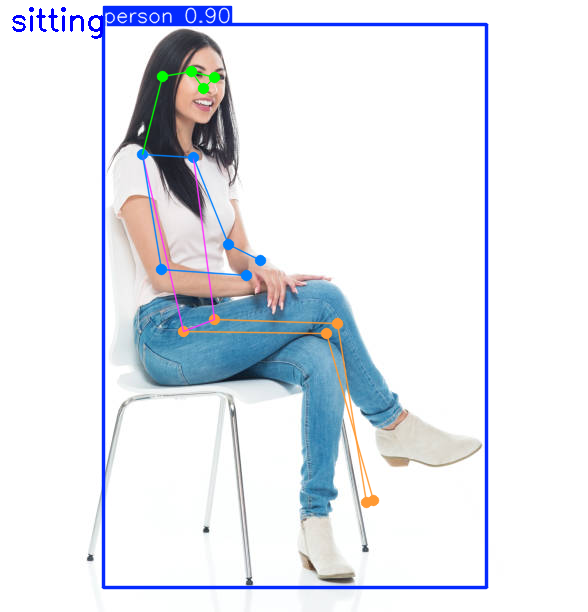


0: 448x640 1 person, 196.2ms
Speed: 4.6ms preprocess, 196.2ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


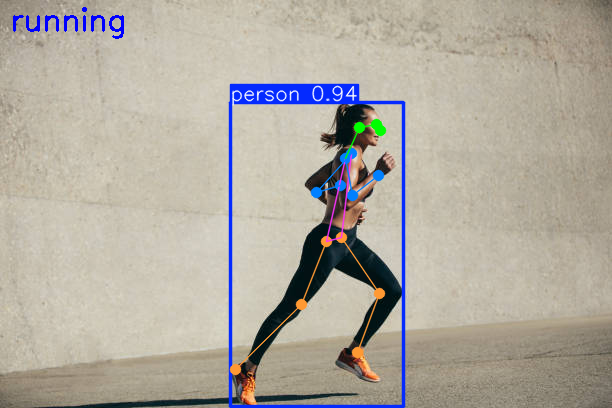


0: 640x480 1 person, 269.8ms
Speed: 5.1ms preprocess, 269.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)


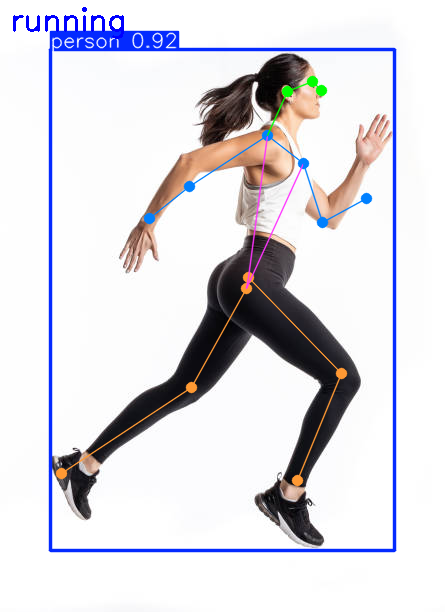


0: 640x448 1 person, 188.5ms
Speed: 8.3ms preprocess, 188.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 448)


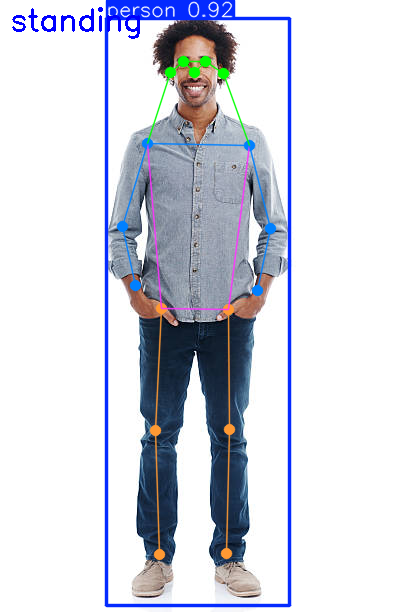


0: 640x448 1 person, 209.9ms
Speed: 4.8ms preprocess, 209.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 448)


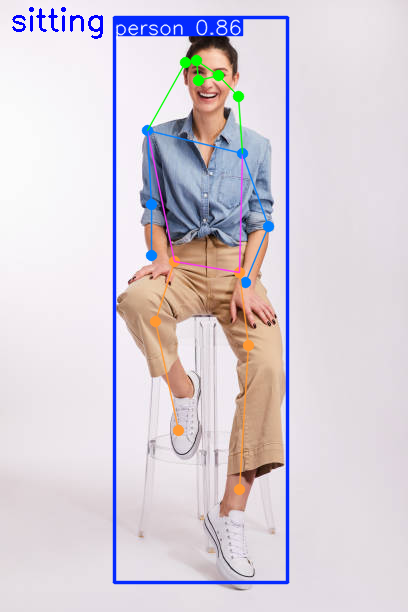


0: 352x640 1 person, 203.4ms
Speed: 4.1ms preprocess, 203.4ms inference, 1.6ms postprocess per image at shape (1, 3, 352, 640)


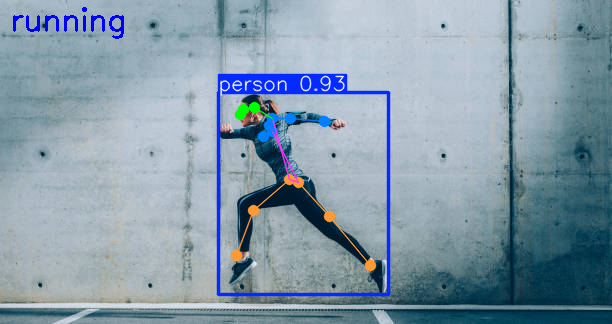


0: 448x640 1 person, 226.4ms
Speed: 4.8ms preprocess, 226.4ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


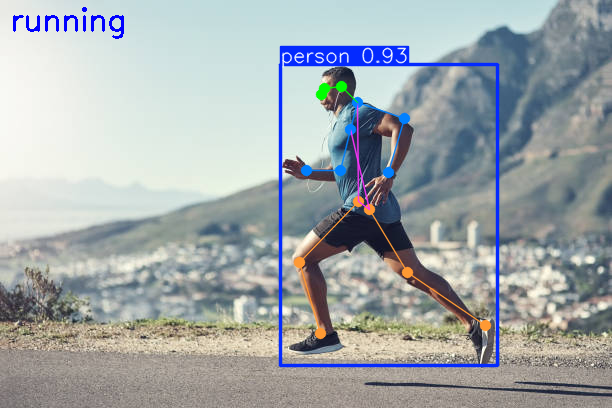


0: 640x448 1 person, 224.6ms
Speed: 5.3ms preprocess, 224.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 448)


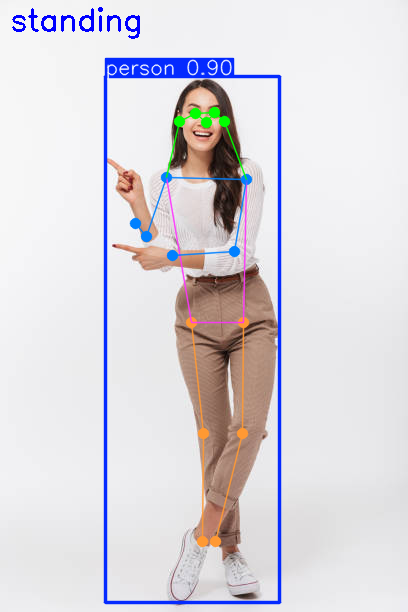


0: 640x448 1 person, 261.6ms
Speed: 4.7ms preprocess, 261.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 448)


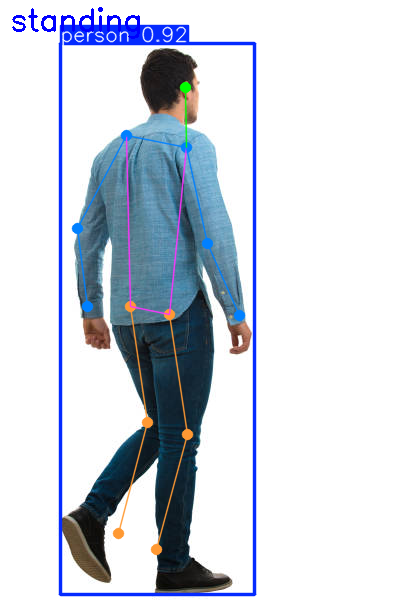


0: 640x448 1 person, 263.4ms
Speed: 4.8ms preprocess, 263.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 448)


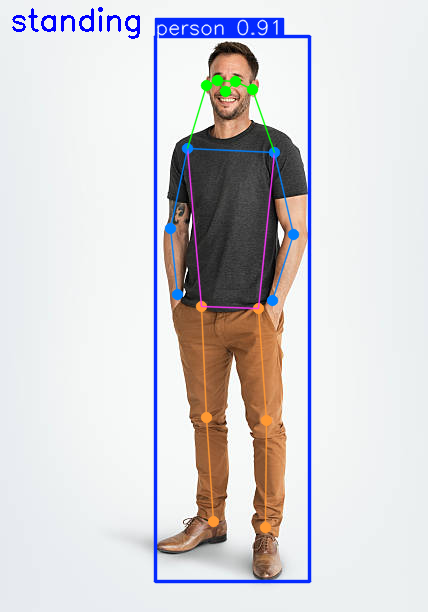

In [ ]:
import numpy as np
import os
from ultralytics import YOLO
import cv2 as cv
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from google.colab.patches import cv2_imshow

image_folder = "/content/AIPractice"
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith(('.jpg', '.png'))]

model = YOLO("yolo11n-pose.pt")

features = []
labels = []

for image_file in image_files:
    img = cv.imread(image_file)
    results = model(img)
    key_points = results[0].keypoints.data.cpu().numpy()

    for person in key_points:
        key_points_flat = person[:, :2].flatten()
        features.append(key_points_flat)

        label = os.path.basename(image_file).split('_')[0]
        labels.append(label)


features = np.array(features)
labels = np.array(labels)


X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

display_count = 0

for image_file in image_files:
    img = cv.imread(image_file)
    results = model(img)

    annotated_img = results[0].plot()

    key_points = results[0].keypoints.data.cpu().numpy()
    for person in key_points:
        key_points_flat = person[:, :2].flatten()
        prediction = knn.predict([key_points_flat])[0]

        cv.putText(annotated_img, prediction, (10, 30), cv.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

    cv2_imshow(annotated_img)
    display_count += 1
    if display_count >= 10:
        break